In [1]:
import vsketch
import numpy as np
from bezmerizing import Polyline
import random
from numpy.random import uniform

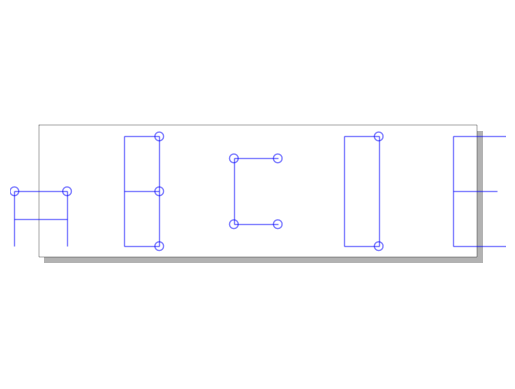

In [8]:
import vsketch
import numpy as np

class LetterGenerator:
    def __init__(self, grid_size=10, vertical_unit=5, horizontal_unit=5, circle_radius=1.5):
        """
        Initialize the letter generator with separate controls for each element
        grid_size: number of cells in the grid (grid_size x grid_size)
        vertical_unit: length unit for vertical lines in mm
        horizontal_unit: length unit for horizontal lines in mm
        circle_radius: radius of circles in mm
        """
        self.grid_size = grid_size
        self.vertical_unit = vertical_unit
        self.horizontal_unit = horizontal_unit
        self.circle_radius = circle_radius
        self.total_height = grid_size * vertical_unit
        self.total_width = grid_size * horizontal_unit
        
    def vertical_line(self, x, y1, y2):
        """Create a vertical line at position x from y1 to y2
        Note: y1 and y2 are in grid units and will be scaled by vertical_unit"""
        points = []
        # Scale the grid coordinates to actual coordinates
        actual_y1 = y1 * self.vertical_unit
        actual_y2 = y2 * self.vertical_unit
        actual_x = x * self.horizontal_unit
        
        steps = max(int(abs(actual_y2 - actual_y1)), 2)
        for i in range(steps + 1):
            t = i / steps
            y = actual_y1 + (actual_y2 - actual_y1) * t
            points.append([actual_x, y])
        return points
    
    def horizontal_line(self, y, x1, x2):
        """Create a horizontal line at position y from x1 to x2
        Note: x1 and x2 are in grid units and will be scaled by horizontal_unit"""
        points = []
        # Scale the grid coordinates to actual coordinates
        actual_x1 = x1 * self.horizontal_unit
        actual_x2 = x2 * self.horizontal_unit
        actual_y = y * self.vertical_unit
        
        steps = max(int(abs(actual_x2 - actual_x1)), 2)
        for i in range(steps + 1):
            t = i / steps
            x = actual_x1 + (actual_x2 - actual_x1) * t
            points.append([x, actual_y])
        return points
    
    def circle(self, x, y, radius_factor=1.0):
        """Create a circle at grid position (x,y) with radius based on circle_radius
        Note: x and y are in grid units and will be scaled by horizontal/vertical units"""
        points = []
        # Scale the grid coordinates to actual coordinates
        actual_x = x * self.horizontal_unit
        actual_y = y * self.vertical_unit
        actual_radius = self.circle_radius * radius_factor
        
        steps = 16  # Number of points to approximate the circle
        for i in range(steps + 1):
            angle = 2 * np.pi * i / steps
            pt_x = actual_x + actual_radius * np.cos(angle)
            pt_y = actual_y + actual_radius * np.sin(angle)
            points.append([pt_x, pt_y])
        return points
    
    def letter_A(self, x_offset=0, y_offset=0):
        """Generate letter A using only horizontal and vertical lines with circles"""
        primitives = []
        
        # Vertical lines for sides (where diagonals would be)
        primitives.append(self.vertical_line(2, 5, 10))  # Left vertical
        primitives.append(self.vertical_line(8, 5, 10))  # Right vertical
        
        # Horizontal line for top
        primitives.append(self.horizontal_line(5, 2, 8))  # Top horizontal
        
        # Horizontal line for crossbar
        primitives.append(self.horizontal_line(7.5, 2, 8))  # Crossbar
        
        # Circles for where diagonal connections would be
        primitives.append(self.circle(2, 5, 1.0))  # Bottom left corner
        primitives.append(self.circle(8, 5, 1.0))  # Bottom right corner
        
        # Apply offset
        for primitive in primitives:
            for point in primitive:
                point[0] += x_offset
                point[1] += y_offset
                
        return primitives
    
    def letter_B(self, x_offset=0, y_offset=0):
        """Generate letter B using only horizontal and vertical lines with circles"""
        primitives = []
        
        # Vertical line for stem
        primitives.append(self.vertical_line(2, 0, 10))  # Vertical stem
        
        # Horizontal lines
        primitives.append(self.horizontal_line(0, 2, 6))   # Top horizontal
        primitives.append(self.horizontal_line(5, 2, 6))   # Middle horizontal
        primitives.append(self.horizontal_line(10, 2, 6))  # Bottom horizontal
        
        # Vertical lines for curves
        primitives.append(self.vertical_line(6, 0, 5))     # Right top vertical
        primitives.append(self.vertical_line(6, 5, 10))    # Right bottom vertical
        
        # Circles for curved connections
        primitives.append(self.circle(6, 0, 1.0))   # Top right corner
        primitives.append(self.circle(6, 5, 1.0))   # Middle right
        primitives.append(self.circle(6, 10, 1.0))  # Bottom right corner
        
        # Apply offset
        for primitive in primitives:
            for point in primitive:
                point[0] += x_offset
                point[1] += y_offset
                
        return primitives
    
    def letter_C(self, x_offset=0, y_offset=0):
        """Generate letter C using only horizontal and vertical lines with circles"""
        primitives = []
        
        # Vertical line for left side
        primitives.append(self.vertical_line(2, 2, 8))  # Left vertical
        
        # Horizontal lines for top and bottom
        primitives.append(self.horizontal_line(2, 2, 7))  # Top horizontal
        primitives.append(self.horizontal_line(8, 2, 7))  # Bottom horizontal
        
        # Circles for the corners
        primitives.append(self.circle(2, 2, 1.0))  # Top left corner
        primitives.append(self.circle(7, 2, 1.0))  # Top right corner
        primitives.append(self.circle(2, 8, 1.0))  # Bottom left corner
        primitives.append(self.circle(7, 8, 1.0))  # Bottom right corner
        
        # Apply offset
        for primitive in primitives:
            for point in primitive:
                point[0] += x_offset
                point[1] += y_offset
                
        return primitives
    
    def letter_D(self, x_offset=0, y_offset=0):
        """Generate letter D using only horizontal and vertical lines with circles"""
        primitives = []
        
        # Vertical line for stem
        primitives.append(self.vertical_line(2, 0, 10))  # Vertical stem
        
        # Horizontal lines
        primitives.append(self.horizontal_line(0, 2, 6))   # Top horizontal
        primitives.append(self.horizontal_line(10, 2, 6))  # Bottom horizontal
        
        # Vertical line for right side
        primitives.append(self.vertical_line(6, 0, 10))  # Right vertical
        
        # Circles for corners
        primitives.append(self.circle(6, 0, 1.0))   # Top right corner
        primitives.append(self.circle(6, 10, 1.0))  # Bottom right corner
        
        # Apply offset
        for primitive in primitives:
            for point in primitive:
                point[0] += x_offset
                point[1] += y_offset
                
        return primitives
    
    def letter_E(self, x_offset=0, y_offset=0):
        """Generate letter E using only horizontal and vertical lines with circles"""
        primitives = []
        
        # Vertical line for stem
        primitives.append(self.vertical_line(2, 0, 10))  # Vertical stem
        
        # Horizontal lines
        primitives.append(self.horizontal_line(0, 2, 8))   # Top horizontal
        primitives.append(self.horizontal_line(5, 2, 7))   # Middle horizontal
        primitives.append(self.horizontal_line(10, 2, 8))  # Bottom horizontal
        
        # Apply offset
        for primitive in primitives:
            for point in primitive:
                point[0] += x_offset
                point[1] += y_offset
                
        return primitives
    
    def draw_letter(self, vsk, letter_func, x_offset=0, y_offset=0):
        """Draw a letter using the provided letter function"""
        primitives = letter_func(x_offset, y_offset)
        
        for primitive in primitives:
            vsk.polygon(primitive)  # Draw as simple polylines

# Create a sketch with the basic alphabet letters
vsk = vsketch.Vsketch()
vsk.size("200mm", "60mm")
vsk.scale("1mm")

# Now using separate variables for each dimension
vertical_unit = 5    # Controls the height of vertical segments
horizontal_unit = 4  # Controls the width of horizontal segments
circle_radius = 2    # Controls the size of circles

letter_gen = LetterGenerator(
    grid_size=10, 
    vertical_unit=vertical_unit, 
    horizontal_unit=horizontal_unit, 
    circle_radius=circle_radius
)

# Draw a row of basic letters
letters = [
    letter_gen.letter_A,
    letter_gen.letter_B,
    letter_gen.letter_C,
    letter_gen.letter_D,
    letter_gen.letter_E
]

# Draw each letter with proper spacing
spacing = max(horizontal_unit, vertical_unit) * 10
for i, letter_func in enumerate(letters):
    with vsk.pushMatrix():
        vsk.translate(20 + i * spacing, 20)
        letter_gen.draw_letter(vsk, letter_func)

vsk.display()